# Zomato Bangalore Restaurants — Exploratory Data Analysis

**A Python-based EDA project**

- **Dataset:** 51,660 restaurant listings scraped from Zomato for Bangalore, India
- **Tools:** Python — pandas, numpy, matplotlib, seaborn
- **Author:** Data Analytics Team
- **Contents:** Data cleaning → Data overview → 12 exploratory analyses (charts + commentary) → Correlation analysis → Business recommendations → Conclusion

---

## Executive Summary

This notebook presents a full exploratory data analysis (EDA) of Bangalore's restaurant market as listed on Zomato. The goal is to understand the competitive landscape — pricing, cuisine popularity, service features, and the factors associated with higher customer ratings — to generate actionable insight for restaurant owners, aggregator platforms, and investors.

**Key takeaways (detailed below):**
1. **Table booking is the strongest quality signal** — restaurants offering it average a **4.14** rating vs **3.62** for those that don't (the largest rating gap in the dataset).
2. **North Indian cuisine and BTM dominate supply** — North Indian is the most common primary cuisine (12,287 restaurants); BTM is the most saturated locality (5,114 listings).
3. **Premium micro-markets exist** — Lavelle Road has the highest average rating (4.14/5) among localities with 30+ restaurants.
4. **Price and popularity both track with quality** — cost vs. rating correlation r = 0.399; votes vs. rating correlation r = 0.434.
5. **Quick Bites lead the format mix** — 19,498 listings, reflecting Bangalore's fast-casual dining culture.


## 1. Setup

In [ ]:
import os
import ast
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["font.size"] = 11

# Zomato brand-inspired palette used throughout
PRIMARY = "#CB202D"   # Zomato red
SECOND  = "#2E2E2E"   # near-black
ACCENT  = "#F5A623"   # amber

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

## 2. Data Loading & Cleaning

Real-world scraped data (`zomato.csv`) requires substantial cleaning before analysis. The pipeline below:

- Drops non-analytical columns (`url`, `phone`, `menu_item`)
- Renames columns to clean snake_case
- Parses `rate` (e.g. `"4.1/5"`) into a numeric `rating` column; `"NEW"` / `"-"` treated as missing
- Converts `approx_cost(for two people)` from a comma-formatted string to numeric, and caps extreme outliers at the 99th percentile (`approx_cost_capped`) for cleaner visuals while preserving the raw values
- Standardizes `online_order` / `book_table` into binary flags (1 = Yes, 0 = No)
- Parses `reviews_list` (a stringified list of tuples) into a `review_count` feature
- Extracts `primary_cuisine`, `cuisine_count` from `cuisines`, and `primary_rest_type` from `rest_type`
- Removes exact duplicate rows and invalid ratings (outside the 1–5 range)

The cell below runs this pipeline automatically if the **raw** `zomato.csv` is present alongside this notebook; otherwise it falls back to the already-cleaned `zomato_clean.csv` so the rest of the notebook always runs end-to-end.

In [ ]:
RAW_PATH   = "zomato.csv"
CLEAN_PATH = "zomato_clean.csv"


def clean_rate(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x in ("NEW", "-", "nan"):
        return np.nan
    x = x.split("/")[0].strip()
    try:
        return float(x)
    except ValueError:
        return np.nan


def clean_cost(x):
    if pd.isna(x):
        return np.nan
    return float(str(x).replace(",", ""))


def count_reviews(reviews_str):
    """Count number of (rating, review) tuples in the reviews_list field."""
    try:
        parsed = ast.literal_eval(reviews_str)
        return len(parsed) if isinstance(parsed, list) else 0
    except (ValueError, SyntaxError, TypeError):
        return 0


def clean_zomato_data(path):
    df = pd.read_csv(path)
    print(f"Raw shape: {df.shape}")

    df = df.drop(columns=["url", "phone", "menu_item"], errors="ignore")
    df = df.rename(columns={
        "approx_cost(for two people)": "approx_cost_for_two",
        "listed_in(type)": "listed_type",
        "listed_in(city)": "listed_city",
    })

    df["rating"] = df["rate"].apply(clean_rate)
    df = df.drop(columns=["rate"])

    df["approx_cost_for_two"] = df["approx_cost_for_two"].apply(clean_cost)

    df["online_order"] = df["online_order"].map({"Yes": 1, "No": 0})
    df["book_table"] = df["book_table"].map({"Yes": 1, "No": 0})

    df["review_count"] = df["reviews_list"].apply(count_reviews)
    df = df.drop(columns=["reviews_list"])

    for col in ["rest_type", "cuisines", "dish_liked", "location", "listed_city"]:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace({"nan": np.nan})

    df["primary_cuisine"] = df["cuisines"].apply(
        lambda x: x.split(",")[0].strip() if pd.notna(x) else np.nan)
    df["cuisine_count"] = df["cuisines"].apply(
        lambda x: len(x.split(",")) if pd.notna(x) else 0)
    df["primary_rest_type"] = df["rest_type"].apply(
        lambda x: x.split(",")[0].strip() if pd.notna(x) else np.nan)

    before = len(df)
    df = df.drop_duplicates()
    print(f"Dropped {before - len(df)} exact duplicate rows")

    df = df[(df["rating"].isna()) | ((df["rating"] >= 1) & (df["rating"] <= 5))]

    cost_cap = df["approx_cost_for_two"].quantile(0.99)
    df["approx_cost_capped"] = df["approx_cost_for_two"].clip(upper=cost_cap)

    print(f"Final shape: {df.shape}")
    return df


if os.path.exists(RAW_PATH):
    df = clean_zomato_data(RAW_PATH)
    df.to_csv(CLEAN_PATH, index=False)
    print("Cleaned data saved to", CLEAN_PATH)
else:
    print(f"'{RAW_PATH}' not found — loading pre-cleaned dataset '{CLEAN_PATH}'.")
    df = pd.read_csv(CLEAN_PATH)

print(df.shape)
df.head()

## 3. Data Overview

In [ ]:
print("Shape:", df.shape)
print()
df.info()

In [ ]:
missing = (df.isna().mean() * 100).round(1).sort_values(ascending=False)
missing = missing[missing > 0]
missing.to_frame("pct_missing")

The cleaned dataset contains **51,660 rows and 18 well-typed columns**. A meaningful share of ratings are missing (~19% — new/unrated listings), which is expected for a live-scraped marketplace and is handled by dropping NaNs on a per-analysis basis rather than imputing them.

In [ ]:
df.describe(include=[np.number]).T

## 4. Analysis

### 4.1 Rating Distribution

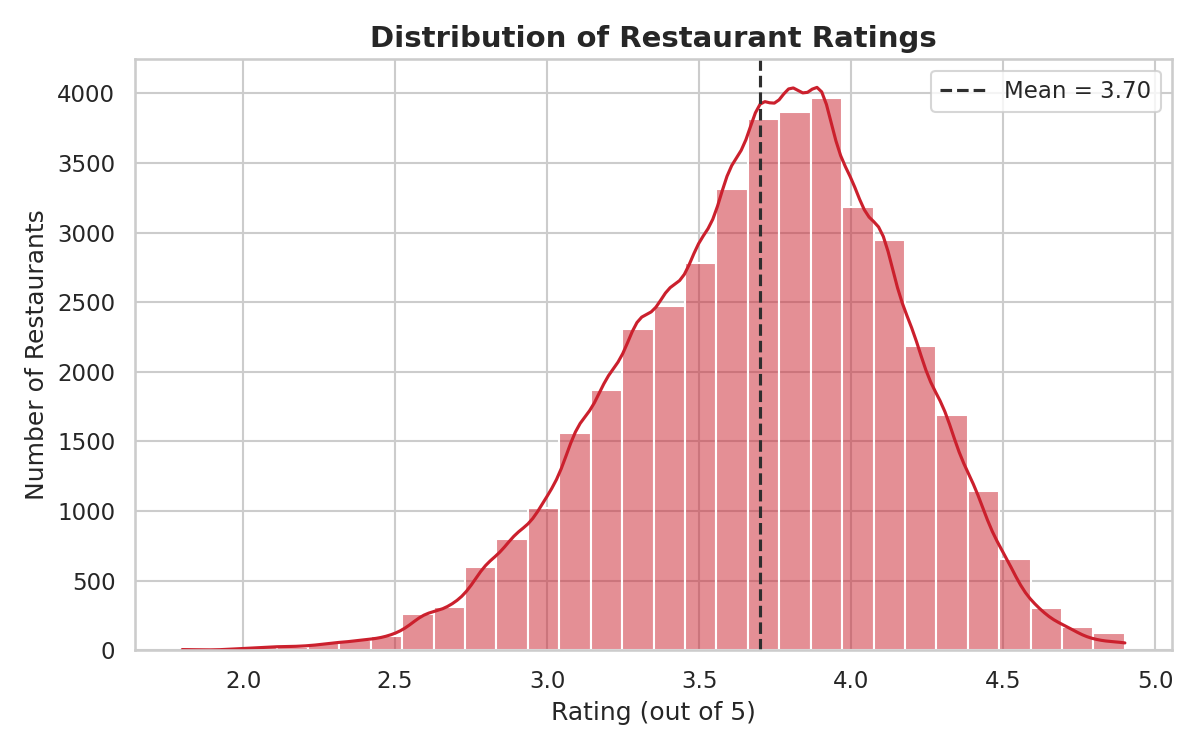

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df["rating"].dropna(), bins=30, color=PRIMARY, kde=True, ax=ax)
ax.axvline(df["rating"].mean(), color=SECOND, linestyle="--",
           label=f"Mean = {df['rating'].mean():.2f}")
ax.set_title("Distribution of Restaurant Ratings", fontsize=14, fontweight="bold")
ax.set_xlabel("Rating (out of 5)")
ax.set_ylabel("Number of Restaurants")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Average rating: {df['rating'].mean():.2f}")
print(f"Median rating:  {df['rating'].median():.2f}")
print(f"% of listings with a rating: {df['rating'].notna().mean()*100:.1f}%")

**Interpretation:** Ratings are approximately bell-shaped and left-skewed, centered around **3.7** (median 3.7). Very few restaurants score below 2.5 or above 4.7 — the rating scale on this dataset is fairly compressed, with most restaurants clustering in the "decent to good" band (3.3–4.2). This makes *relative* comparisons across restaurants far more meaningful than absolute scores.

### 4.2 Impact of Online Ordering

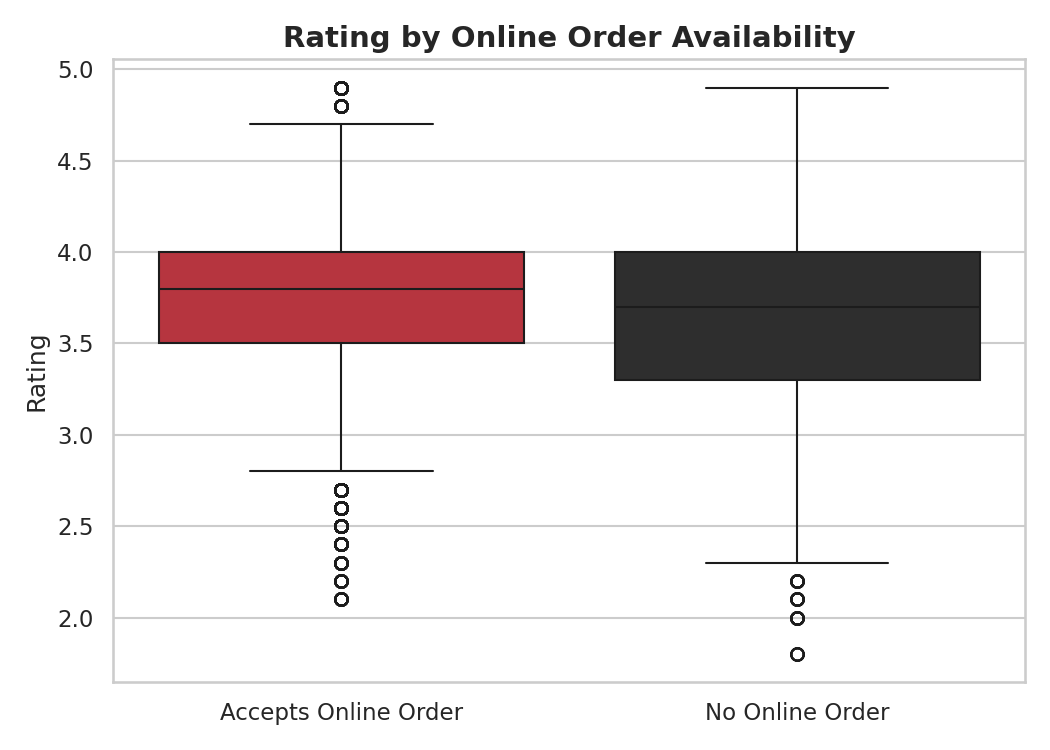

In [ ]:
order_map = {1: "Accepts Online Order", 0: "No Online Order"}
plot_df = df.copy()
plot_df["online_order_label"] = plot_df["online_order"].map(order_map)

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=plot_df, x="online_order_label", y="rating",
            hue="online_order_label", palette=[PRIMARY, SECOND], legend=False, ax=ax)
ax.set_title("Rating by Online Order Availability", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Rating")
plt.tight_layout()
plt.show()

online_pct = df["online_order"].mean() * 100
avg_online = df.loc[df["online_order"] == 1, "rating"].mean()
avg_offline = df.loc[df["online_order"] == 0, "rating"].mean()
print(f"% accepting online orders: {online_pct:.1f}%")
print(f"Avg rating (online):  {avg_online:.2f}")
print(f"Avg rating (offline): {avg_offline:.2f}")

**Interpretation:** **58.8%** of listings accept online orders. Restaurants offering online ordering have a marginally higher average rating (**3.72**) than those that don't (**3.66**). The effect is real but modest — online ordering looks like **table stakes** rather than a strong differentiator on its own.

### 4.3 Impact of Table Booking

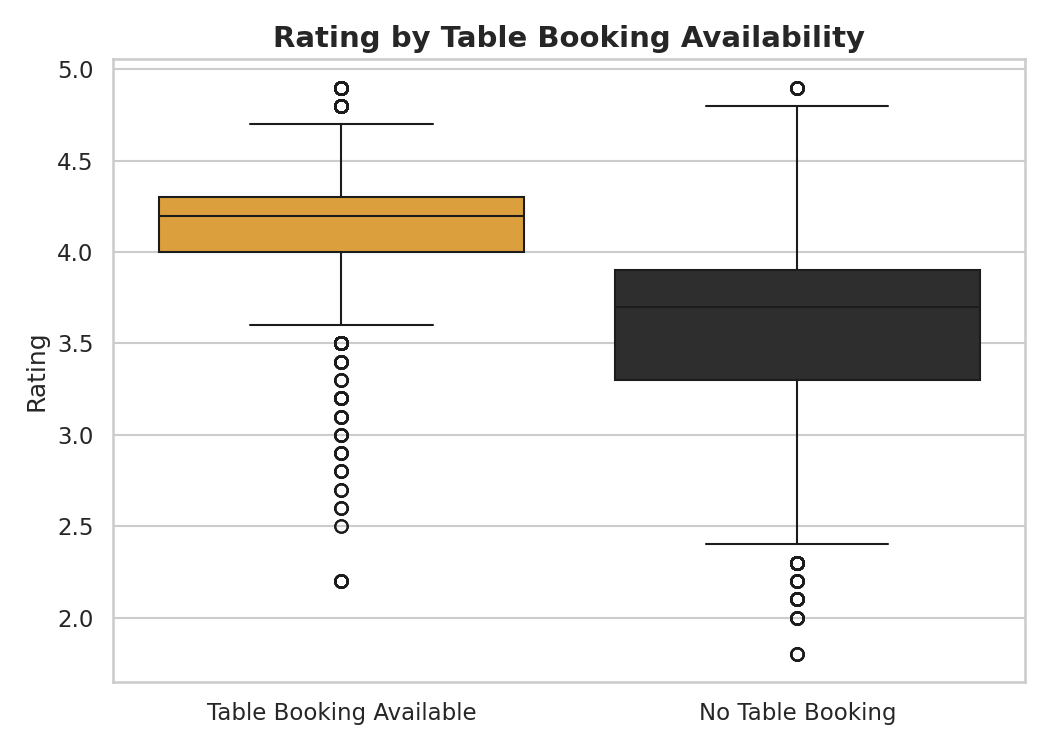

In [ ]:
plot_df["book_table_label"] = plot_df["book_table"].map(
    {1: "Table Booking Available", 0: "No Table Booking"})

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=plot_df, x="book_table_label", y="rating",
            hue="book_table_label", palette=[ACCENT, SECOND], legend=False, ax=ax)
ax.set_title("Rating by Table Booking Availability", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Rating")
plt.tight_layout()
plt.show()

book_pct = df["book_table"].mean() * 100
avg_book = df.loc[df["book_table"] == 1, "rating"].mean()
avg_nobook = df.loc[df["book_table"] == 0, "rating"].mean()
print(f"% offering table booking: {book_pct:.1f}%")
print(f"Avg rating (table booking):    {avg_book:.2f}")
print(f"Avg rating (no table booking): {avg_nobook:.2f}")
print(f"Gap: {avg_book - avg_nobook:.2f} points")

**Interpretation:** Table booking shows the **strongest relationship with rating in the entire dataset**. Only **12.5%** of restaurants offer it, but those that do average **4.14** vs **3.62** for those that don't — a gap of **0.52 points**. Table booking tends to be offered by more established, higher-service-standard restaurants (fine dining, reservation-based casual dining), which explains the strong association.

### 4.4 Geographic Concentration — Top Localities by Volume

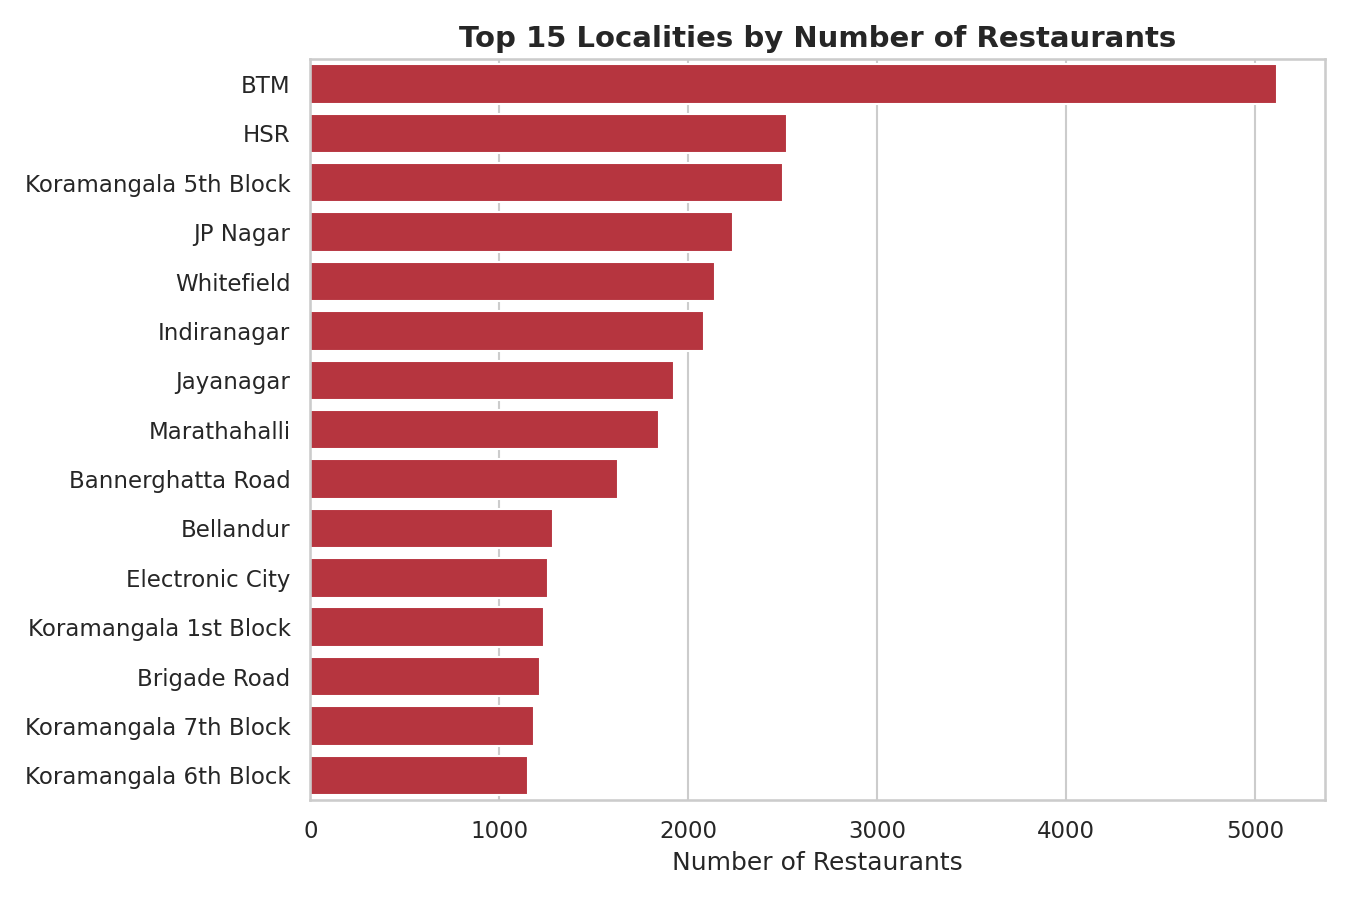

In [ ]:
top_locations = df["location"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=top_locations.values, y=top_locations.index, color=PRIMARY, ax=ax)
ax.set_title("Top 15 Localities by Number of Restaurants", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Restaurants")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

print(f"Top locality: {top_locations.index[0]} ({top_locations.iloc[0]:,} listings)")
print(f"Unique localities tracked: {df['location'].nunique()}")

**Interpretation:** Restaurant supply is highly concentrated. **BTM** alone hosts **5,114** listings, and the top 15 localities account for a large share of the market across **93** total localities tracked. But as the next chart shows, raw restaurant count does **not** equal quality.

### 4.5 Cuisine Landscape — Most Common Cuisines

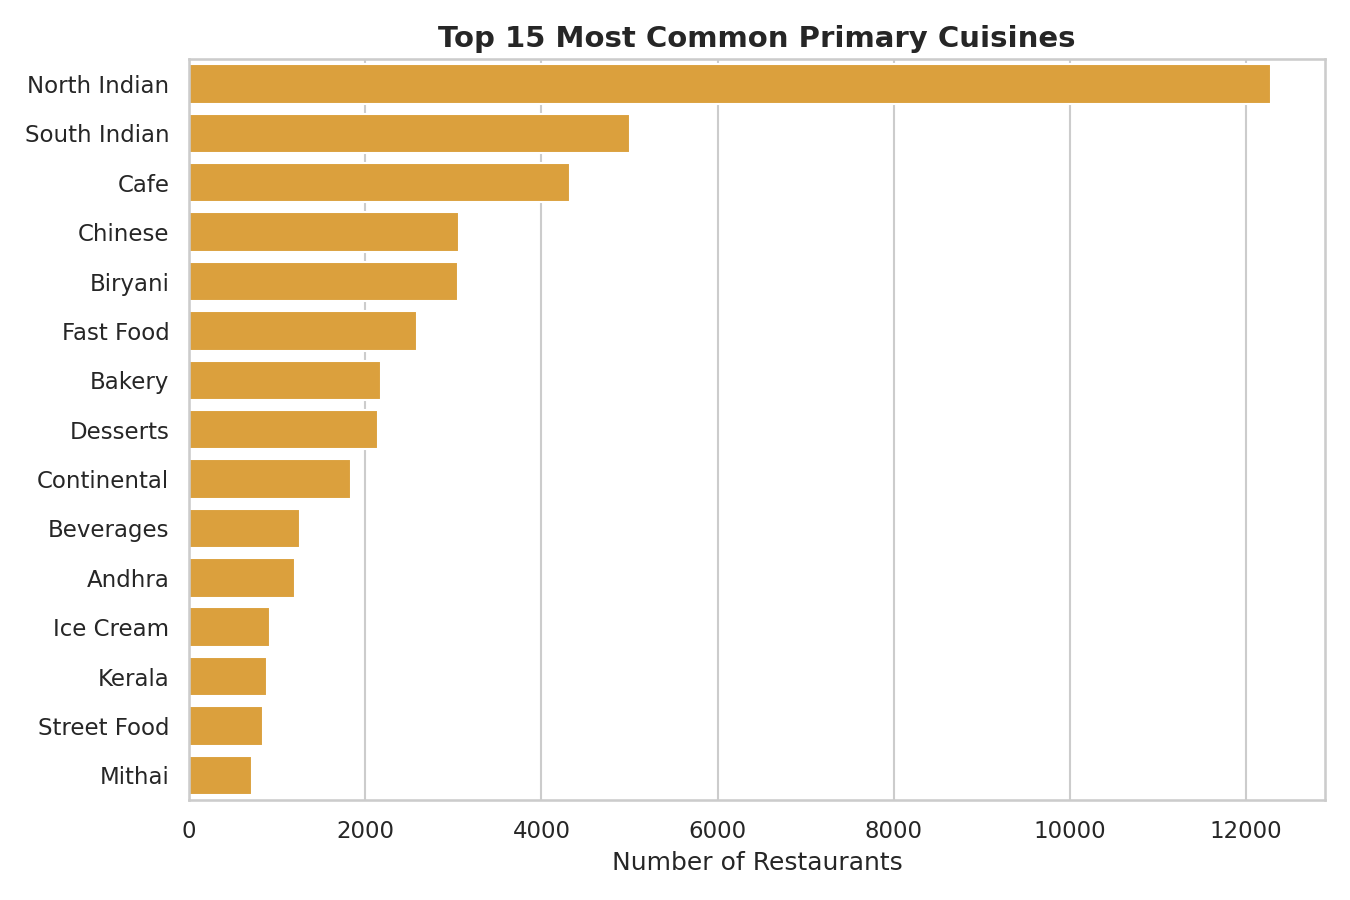

In [ ]:
top_cuisines = df["primary_cuisine"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index, color=ACCENT, ax=ax)
ax.set_title("Top 15 Most Common Primary Cuisines", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Restaurants")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

print(f"Top cuisine: {top_cuisines.index[0]} ({top_cuisines.iloc[0]:,} listings)")
print(f"Unique cuisine combinations: {df['cuisines'].nunique():,}")

**Interpretation:** **North Indian** is the single most common primary cuisine, appearing in **12,287** listings — broad, mainstream demand. Considering full cuisine combinations (e.g. "North Indian, Chinese"), the dataset contains **2,723** distinct combinations, showing most restaurants differentiate by blending 2–3 cuisines rather than specializing narrowly.

### 4.6 Restaurant Format Mix

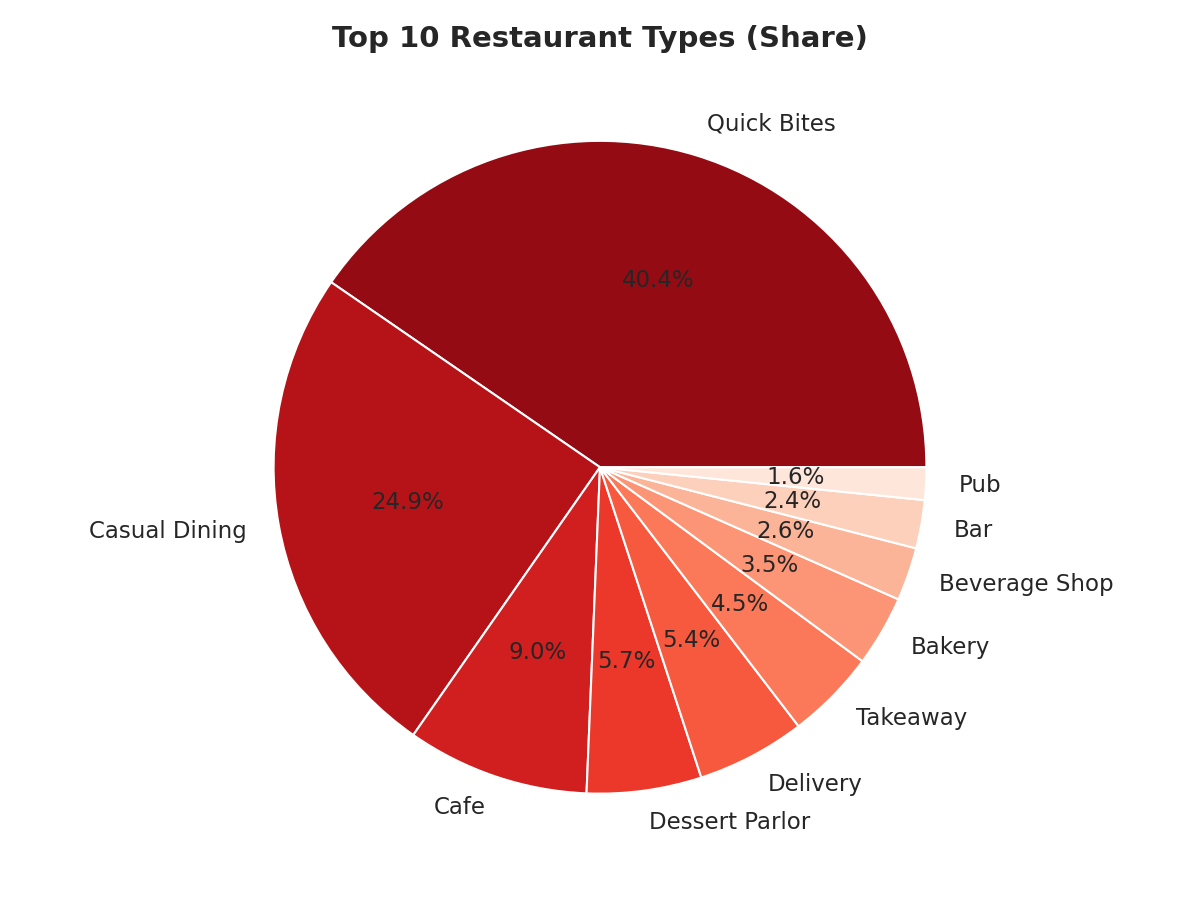

In [ ]:
top_types = df["primary_rest_type"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(8, 6))
colors = sns.color_palette("Reds_r", len(top_types))
ax.pie(top_types.values, labels=top_types.index, autopct="%1.1f%%", colors=colors,
       wedgeprops={"edgecolor": "white", "linewidth": 1})
ax.set_title("Top 10 Restaurant Types (Share)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Top format: {top_types.index[0]} ({top_types.iloc[0]:,} listings)")

**Interpretation:** **Quick Bites** is the dominant restaurant format in Bangalore, with **19,498** listings — consistent with a market driven by convenience, delivery, and casual on-the-go dining rather than formal sit-down experiences.

### 4.7 Pricing Analysis

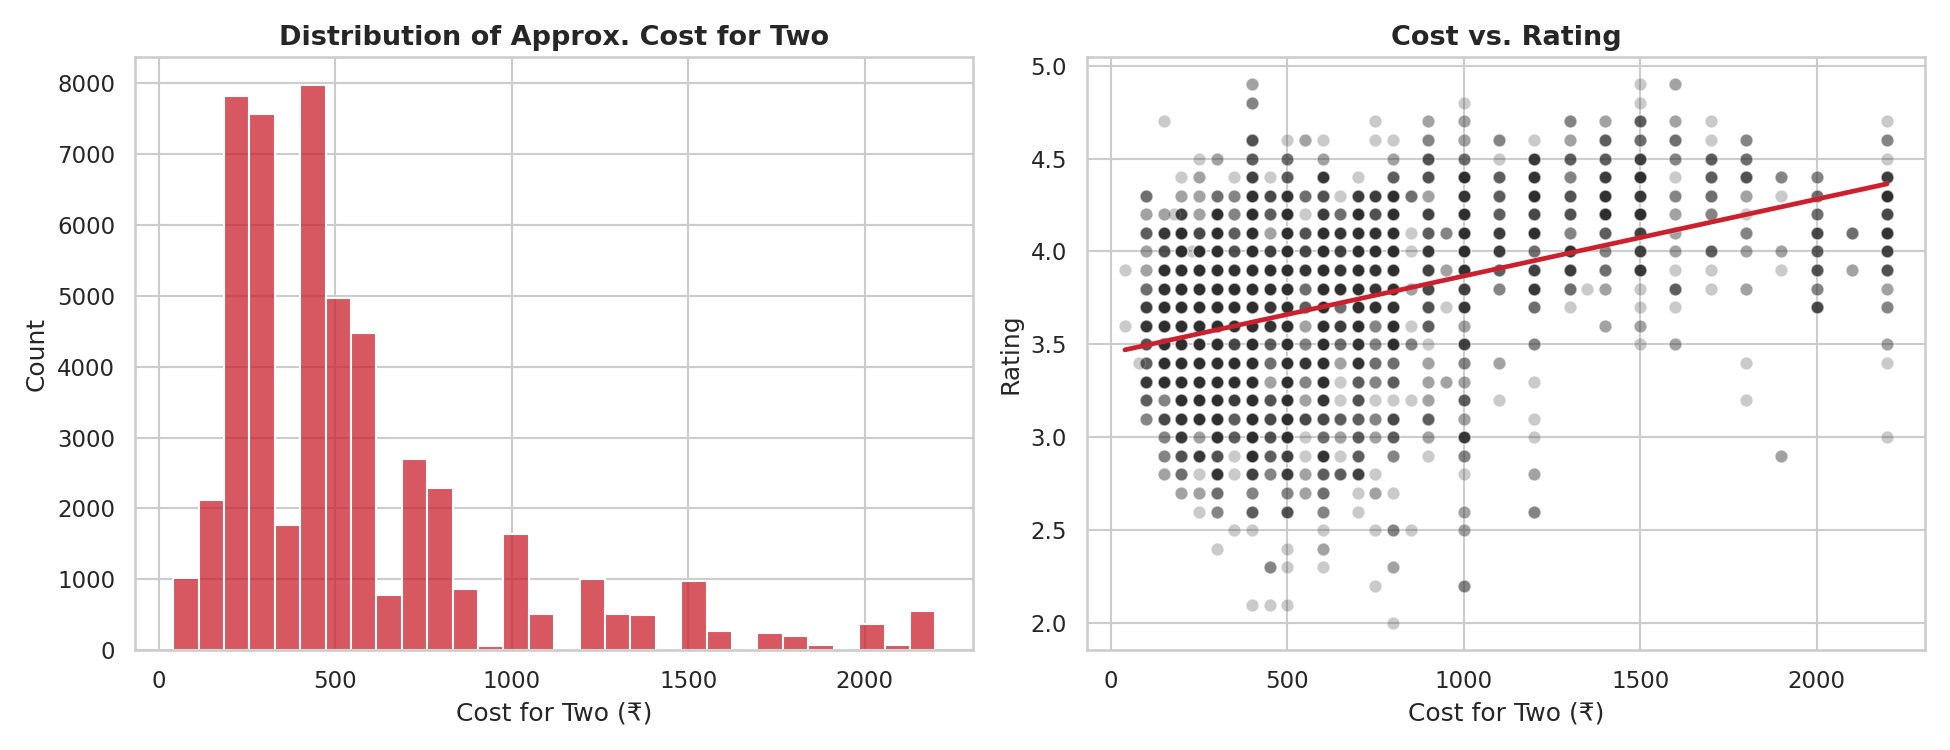

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df["approx_cost_capped"].dropna(), bins=30, color=PRIMARY, ax=axes[0])
axes[0].set_title("Distribution of Approx. Cost for Two", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Cost for Two (₹)")

sample = df.sample(min(6000, len(df)), random_state=42)
sns.scatterplot(data=sample, x="approx_cost_capped", y="rating",
                 alpha=0.25, color=SECOND, ax=axes[1])
sns.regplot(data=df, x="approx_cost_capped", y="rating", scatter=False,
            color=PRIMARY, ax=axes[1])
axes[1].set_title("Cost vs. Rating", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Cost for Two (₹)")
axes[1].set_ylabel("Rating")

plt.tight_layout()
plt.show()

cost_rating_corr = df[["approx_cost_capped", "rating"]].corr().iloc[0, 1]
print(f"Average cost for two: ₹{df['approx_cost_for_two'].mean():.0f}")
print(f"Median cost for two:  ₹{df['approx_cost_for_two'].median():.0f}")
print(f"Cost vs rating correlation: r = {cost_rating_corr:.3f}")

**Interpretation:** The average cost for two is **₹555** (median ₹400), reflecting a market skewed toward affordable dining with a long tail of premium establishments. Cost shows a **moderate positive correlation with rating (r = 0.399)** — pricier restaurants tend to invest more in food quality, ambience, and service, which shows up in ratings, though the relationship is far from deterministic.

### 4.8 Popularity vs. Quality — Votes vs. Rating

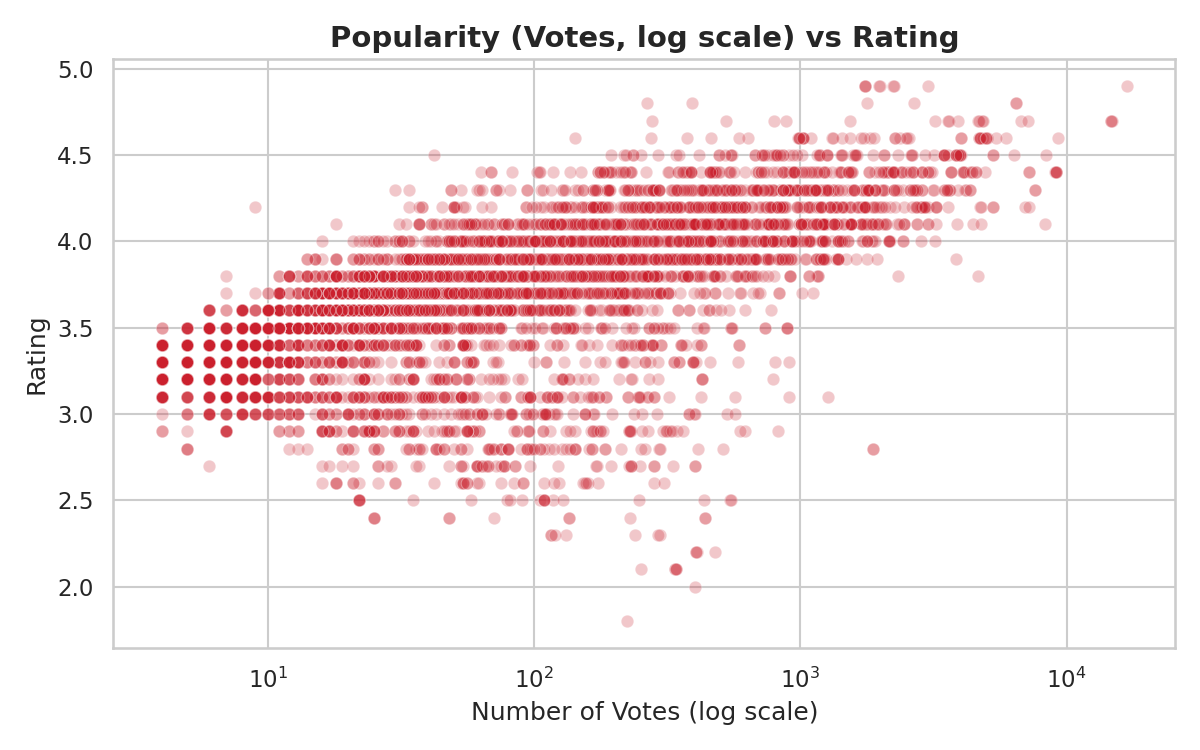

In [ ]:
voted = df[df["votes"] > 0]
sample = voted.sample(min(6000, len(voted)), random_state=42)

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=sample, x="votes", y="rating", alpha=0.25, color=PRIMARY, ax=ax)
ax.set_xscale("log")
ax.set_title("Popularity (Votes, log scale) vs Rating", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Votes (log scale)")
ax.set_ylabel("Rating")
plt.tight_layout()
plt.show()

votes_rating_corr = df[["votes", "rating"]].corr().iloc[0, 1]
print(f"Votes vs rating correlation: r = {votes_rating_corr:.3f}")

**Interpretation:** Number of votes correlates with rating at **r = 0.434**, a stronger relationship than cost. This makes intuitive sense: restaurants that are genuinely good accumulate more repeat visits and reviews, creating a reinforcing cycle. Restaurants with very few votes show much higher rating volatility, since a handful of reviews can swing an average sharply in either direction.

### 4.9 Service-Category Mix

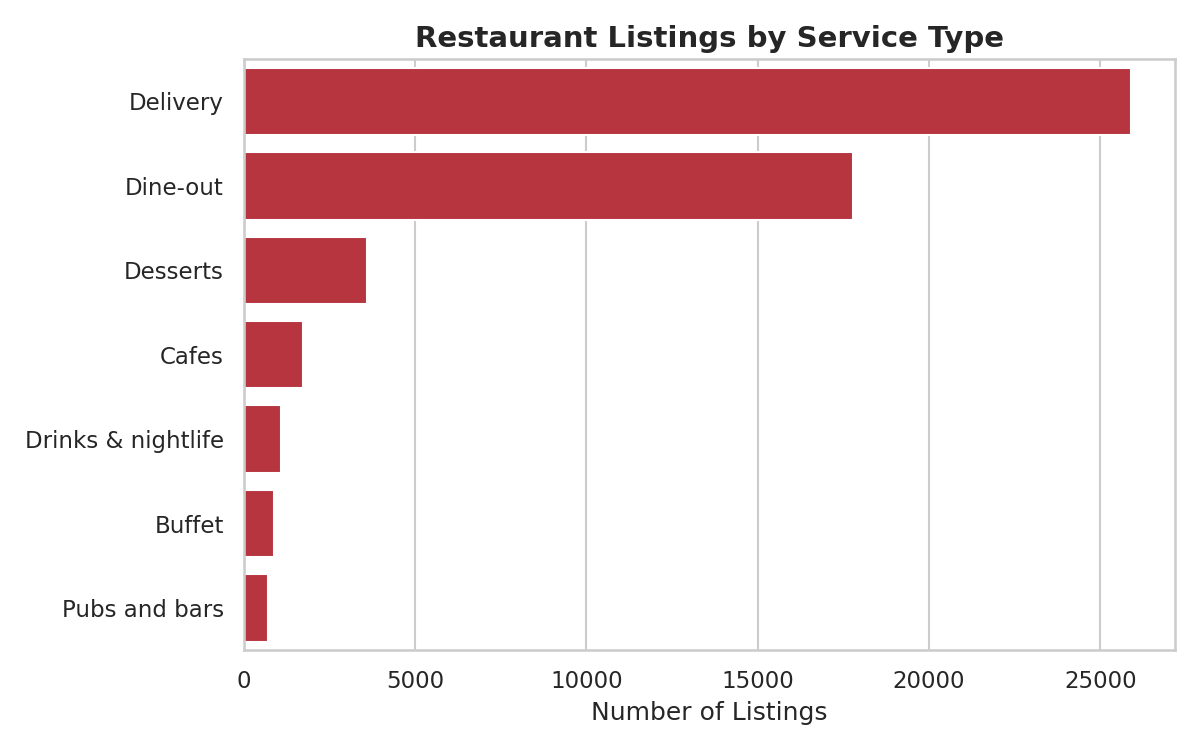

In [ ]:
type_counts = df["listed_type"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=type_counts.values, y=type_counts.index, color=PRIMARY, ax=ax)
ax.set_title("Restaurant Listings by Service Type", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Listings")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

type_counts

**Interpretation:** Listings break down across Zomato's service categories (Delivery, Dine-out, Buffet, etc.) — note a single physical restaurant can appear multiple times if listed under several service categories, which partly explains the 51,660-row count against ~8,792 unique restaurant names.

### 4.10 Highest-Rated Localities (Quality Leaders)

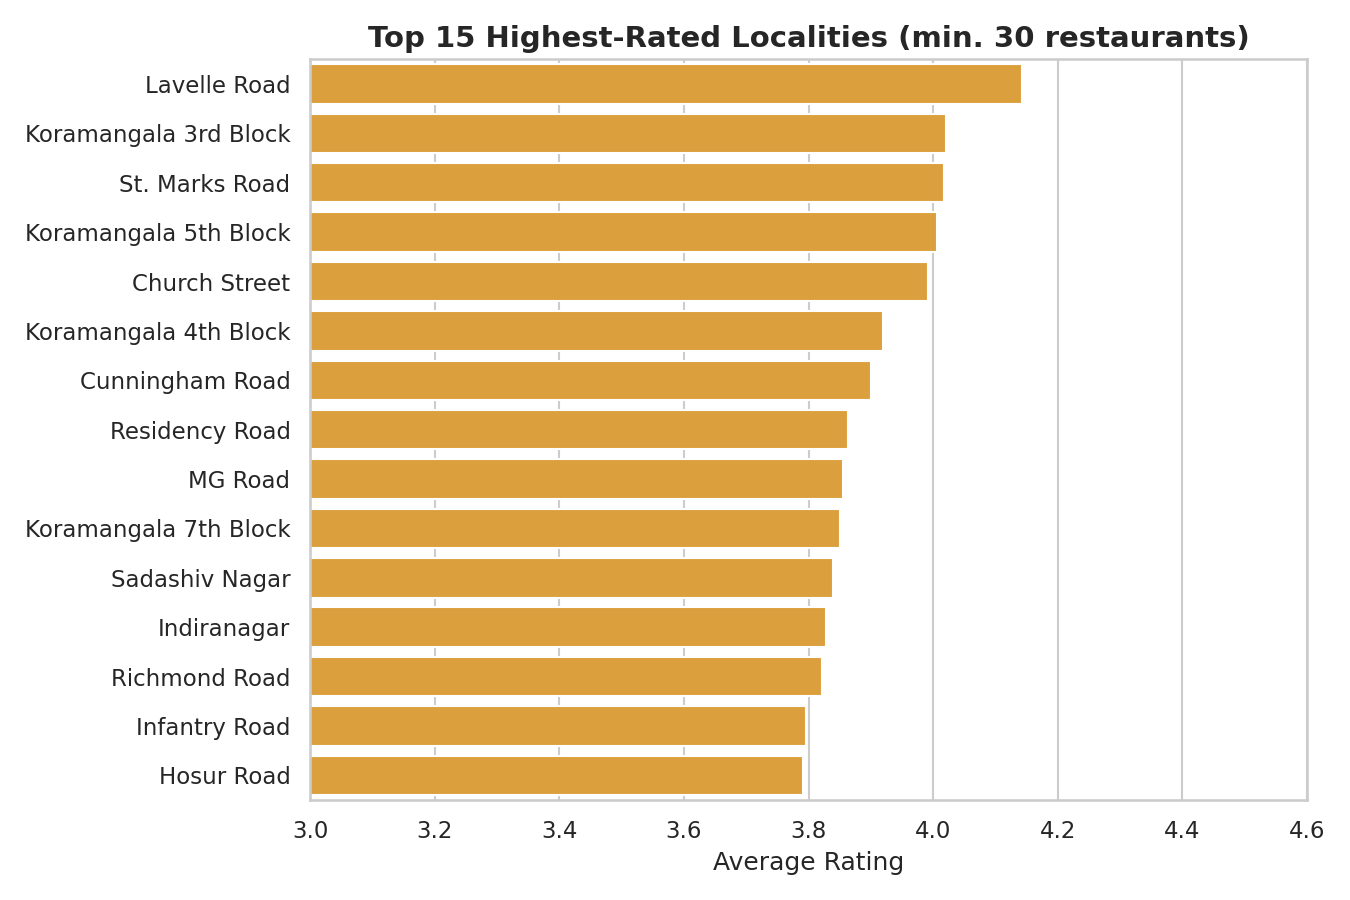

In [ ]:
loc_stats = df.groupby("location").agg(avg_rating=("rating", "mean"), count=("rating", "count"))
loc_stats = loc_stats[loc_stats["count"] >= 30].sort_values("avg_rating", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=loc_stats["avg_rating"], y=loc_stats.index, color=ACCENT, ax=ax)
ax.set_xlim(3.0, 4.6)
ax.set_title("Top 15 Highest-Rated Localities (min. 30 restaurants)", fontsize=14, fontweight="bold")
ax.set_xlabel("Average Rating")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

print(f"Best locality: {loc_stats.index[0]} (avg rating {loc_stats['avg_rating'].iloc[0]:.2f})")

**Interpretation:** Restricting to localities with at least 30 restaurants (to avoid small-sample noise), **Lavelle Road** leads with an average rating of **4.14** — a different leaderboard than the volume ranking in 4.4, pointing to a cluster of premium dining establishments rather than the highest-density areas.

### 4.11 Menu Breadth vs. Rating

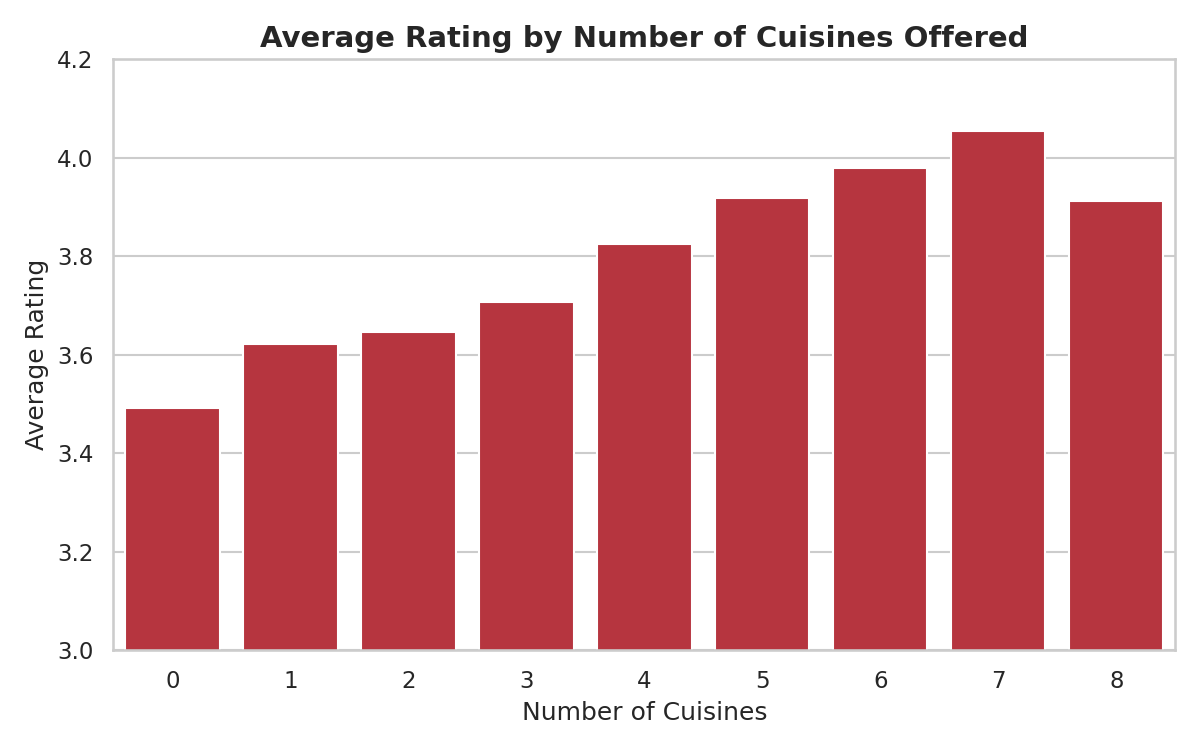

In [ ]:
cc = df.groupby("cuisine_count")["rating"].mean().reset_index()
cc = cc[cc["cuisine_count"] <= 8]

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=cc, x="cuisine_count", y="rating",
            hue="cuisine_count", palette=[PRIMARY] * len(cc), legend=False, ax=ax)
ax.set_title("Average Rating by Number of Cuisines Offered", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Cuisines")
ax.set_ylabel("Average Rating")
ax.set_ylim(3.0, 4.2)
plt.tight_layout()
plt.show()

cc

**Interpretation:** Restaurants offering a moderate number of cuisines (**2–4**) tend to rate slightly better than ultra-specialized single-cuisine spots or those spreading themselves across many cuisines — a "focused but not narrow" sweet spot.

### 4.12 Correlation Summary

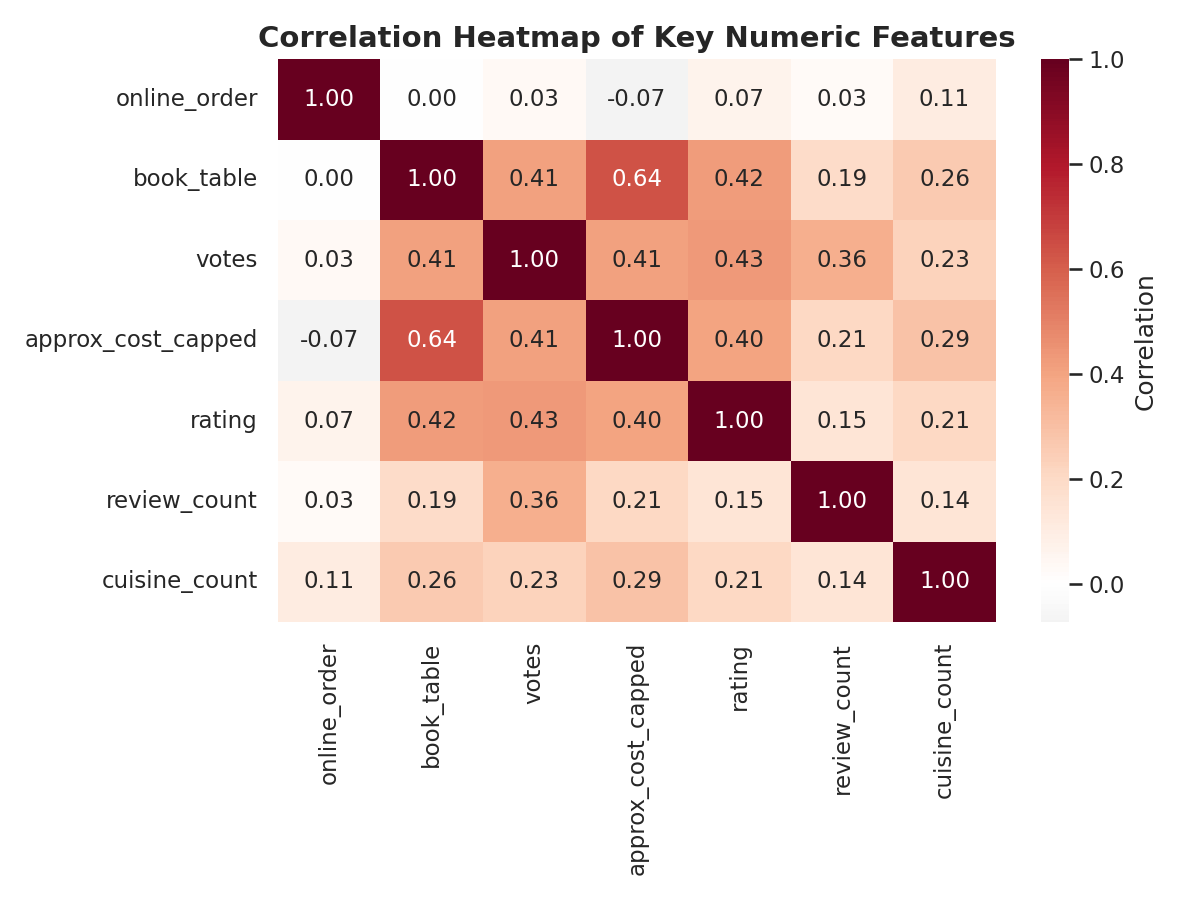

In [ ]:
num_cols = ["online_order", "book_table", "votes", "approx_cost_capped",
            "rating", "review_count", "cuisine_count"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdGy_r", center=0, ax=ax,
            cbar_kws={"label": "Correlation"})
ax.set_title("Correlation Heatmap of Key Numeric Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

corr

**Interpretation:** Votes and rating show the strongest positive correlation, followed by cost. Online ordering and table booking show weaker but positive associations with rating, consistent with the boxplot findings in 4.2 and 4.3.

## 5. Summary Statistics

In [ ]:
summary = {
    "total_restaurants": int(len(df)),
    "total_unique_names": int(df["name"].nunique()),
    "avg_rating": round(df["rating"].mean(), 2),
    "median_rating": round(df["rating"].median(), 2),
    "pct_rated": round(df["rating"].notna().mean() * 100, 1),
    "online_order_pct": round(df["online_order"].mean() * 100, 1),
    "avg_rating_online": round(df.loc[df["online_order"] == 1, "rating"].mean(), 2),
    "avg_rating_offline": round(df.loc[df["online_order"] == 0, "rating"].mean(), 2),
    "book_table_pct": round(df["book_table"].mean() * 100, 1),
    "avg_rating_book_table": round(df.loc[df["book_table"] == 1, "rating"].mean(), 2),
    "avg_rating_no_book_table": round(df.loc[df["book_table"] == 0, "rating"].mean(), 2),
    "top_location": top_locations.index[0],
    "top_location_count": int(top_locations.iloc[0]),
    "unique_locations": int(df["location"].nunique()),
    "top_cuisine": top_cuisines.index[0],
    "top_cuisine_count": int(top_cuisines.iloc[0]),
    "unique_cuisines_combo": int(df["cuisines"].nunique()),
    "top_rest_type": top_types.index[0],
    "top_rest_type_count": int(top_types.iloc[0]),
    "avg_cost_for_two": round(df["approx_cost_for_two"].mean(), 0),
    "median_cost_for_two": round(df["approx_cost_for_two"].median(), 0),
    "cost_rating_corr": round(cost_rating_corr, 3),
    "votes_rating_corr": round(votes_rating_corr, 3),
    "best_locality": loc_stats.index[0],
    "best_locality_rating": round(loc_stats["avg_rating"].iloc[0], 2),
}

with open("summary_stats.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)

print(json.dumps(summary, indent=2, default=str))

## 6. Business Recommendations

**For Restaurant Owners**
1. **Enable table reservations** where feasible — it shows the strongest association with higher ratings, likely reflecting the operational maturity and service quality that customers reward.
2. **Treat online ordering as a baseline requirement**, not a differentiator — competitive advantage needs to come from food quality and service.
3. **Offer 2–4 complementary cuisines** rather than an overly narrow or overly broad menu, matching the sweet spot observed in the rating data.
4. **Evaluate expansion into under-served, high-rated localities** (e.g. Lavelle Road) rather than the most saturated hubs like BTM.

**For Zomato / Aggregator Platforms**
1. **Use vote count as a leading indicator of quality** for ranking algorithms, since it correlates more strongly with rating than price does.
2. **Introduce a "new / low-review" confidence flag** for restaurants with very few votes, where rating volatility is high, to avoid misleading users.
3. **Support restaurants in saturated localities** with differentiation tools (cuisine tagging, promotions), since raw restaurant density does not guarantee customer satisfaction.

**For Investors**
1. **Favor locations and formats with structurally higher ratings** (e.g. table-booking-enabled casual/fine dining in high-rated micro-markets) over the most saturated quick-bite segments, which face intense price competition.

## 7. Conclusion

This analysis of **51,660** Zomato Bangalore restaurant listings shows that customer ratings are shaped less by price alone and more by **service maturity signals** — particularly table booking availability — combined with **sustained popularity** (votes). Bangalore's restaurant market remains heavily concentrated in a handful of localities and dominated by quick-bite formats and North Indian-led multi-cuisine offerings, but pockets of higher-rated, lower-density localities represent attractive opportunities for new entrants.

The full pipeline in this notebook (data cleaning → EDA → correlation analysis → recommendations) is reproducible end-to-end: drop the raw `zomato.csv` alongside this notebook and re-run all cells to regenerate every chart and statistic from scratch.